<a href="https://colab.research.google.com/github/alejitovm97-byte/Alejo-Varelas-projects/blob/main/01_QMJ_analysis_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# ============================================================
# NOTEBOOK 01 — Factor Analysis (Quality + Value + Momentum)
# Based on:
#   - Asness, Frazzini & Pedersen (2017) "Quality Minus Junk"
#   - Asness, Moskowitz & Pedersen (2013) "Value and Momentum Everywhere"
# ============================================================

# --- Core ---
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, ttest_1samp

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Settings ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded")

✓ Libraries loaded


In [28]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/TFM/Datos/'

import os
os.makedirs('/content/drive/MyDrive/TFM/outputs', exist_ok=True)
archivos = os.listdir(BASE)
print(f"✓ Drive mounted — {len(archivos)} files found")
for f in sorted(archivos):
    print(f"  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted — 11 files found
  daily_historicals.xlsx
  daily_historicals_v2.xlsx
  daily_prices_refinitiv_all.csv
  daily_sp500.xlsx
  evol_historicals.xlsx
  evol_sp500.xlsx
  fundamentals_historicals.xlsx
  fundamentals_sp500.xlsx
  price_close_d_sp500.xlsx
  price_close_m_historicals.xlsx
  price_close_m_sp500.xlsx


In [29]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_refinitiv(path, verbose=True):
    """
    Load a Refinitiv Excel export and return a clean long-format DataFrame.
    Handles FY, FQ, and CM period labels.
    """
    df_raw = pd.read_excel(path, header=None)
    if verbose:
        print(f"  Raw shape: {df_raw.shape}")

    row_headers = df_raw.iloc[0]
    row_periods = df_raw.iloc[1]

    # Normalize period labels: FY0 → FY-0, FQ0 → FQ-0, CM0 → CM-0
    for col_idx in range(df_raw.shape[1]):
        val = row_periods[col_idx]
        if pd.notna(val) and isinstance(val, str):
            if val in ('FY0', 'FQ0', 'CM0'):
                df_raw.iloc[1, col_idx] = val.replace('0', '-0')
    row_periods = df_raw.iloc[1]

    fixed_cols = []
    var_blocks = []
    current_var = None
    current_start = None

    for col_idx in range(df_raw.shape[1]):
        header_val = row_headers[col_idx]
        period_val = row_periods[col_idx]

        if pd.notna(header_val):
            if pd.isna(period_val):
                if current_var is not None:
                    var_blocks.append((current_var, current_start, col_idx - 1))
                    current_var = None
                fixed_cols.append((col_idx, header_val.split('\n')[0].strip()))
            else:
                if current_var is not None:
                    var_blocks.append((current_var, current_start, col_idx - 1))
                current_var = header_val.split('\n')[0].strip()
                current_start = col_idx

    if current_var is not None:
        var_blocks.append((current_var, current_start, df_raw.shape[1] - 1))

    df_data = df_raw.iloc[3:].reset_index(drop=True)

    fixed_df = pd.DataFrame()
    for col_idx, col_name in fixed_cols:
        fixed_df[col_name] = df_data[col_idx]

    first_fixed = fixed_df.columns[0]
    fixed_df = fixed_df.rename(columns={first_fixed: 'ric'})
    if len(fixed_df.columns) > 1:
        fixed_df = fixed_df.rename(columns={fixed_df.columns[1]: 'company_name'})

    results = {}
    for var_name, start_col, end_col in var_blocks:
        period_labels = [row_periods[c] for c in range(start_col, end_col + 1)]
        values_wide = df_data[list(range(start_col, end_col + 1))]
        values_wide.columns = period_labels

        melted = pd.concat([fixed_df.reset_index(drop=True), values_wide], axis=1)
        id_cols = list(fixed_df.columns)
        melted = melted.melt(id_vars=id_cols, var_name='period_label', value_name='value')
        melted['value'] = pd.to_numeric(melted['value'], errors='coerce')
        melted = melted.dropna(subset=['ric'])
        results[var_name] = melted

    if verbose:
        print(f"  Fixed columns: {list(fixed_df.columns)}")
        print(f"  Variable blocks: {len(var_blocks)}")
        for var_name, start, end in var_blocks:
            print(f"    '{var_name}' → {end - start + 1} periods")

    return results


def rank_zscore(series):
    """Cross-sectional rank z-score (Asness et al. 2017, Eq. 2)."""
    r = series.rank(method='average', na_option='keep')
    return (r - r.mean()) / r.std()


def rank_zscore_by_sector(df, col, sector_col='sector'):
    """Apply rank_zscore within each sector."""
    return df.groupby(sector_col)[col].transform(rank_zscore)


def delta_5y(df, numerator_col, denominator_col, group_col='ric'):
    """
    Five-year growth (QMJ Appendix A1):
    Δ = (numerator_t - numerator_{t-5}) / denominator_{t-5}
    """
    def _calc(g):
        num_now = g[numerator_col].values
        num_lag = g[numerator_col].shift(5).values
        den_lag = g[denominator_col].shift(5).values
        with np.errstate(divide='ignore', invalid='ignore'):
            result = (num_now - num_lag) / np.where(den_lag == 0, np.nan, den_lag)
        return pd.Series(result, index=g.index)
    return df.groupby(group_col, group_keys=False).apply(_calc)


print("✓ Helper functions defined")

✓ Helper functions defined


In [30]:
# ============================================================
# SECCIÓN 2 — CARGA DE DATOS
# ============================================================

# 2.1 — Load all files (3 pairs: fundamentals, evol, monthly prices)

file_pairs = {
    'fundamentals': ('fundamentals_sp500.xlsx', 'fundamentals_historicals.xlsx'),
    'evol':         ('evol_sp500.xlsx', 'evol_historicals.xlsx'),
}

raw_data = {}

for name, (sp500_file, hist_file) in file_pairs.items():
    print(f"\n{'='*50}")
    print(f"Loading: {name}")

    print(f"  → SP500: {sp500_file}")
    sp500 = load_refinitiv(BASE + sp500_file)

    print(f"  → Historical: {hist_file}")
    hist = load_refinitiv(BASE + hist_file)

    combined = {}
    all_vars = set(list(sp500.keys()) + list(hist.keys()))

    for var in all_vars:
        parts = []
        if var in sp500:
            parts.append(sp500[var])
        if var in hist:
            parts.append(hist[var])

        df_combined = pd.concat(parts, ignore_index=True)
        df_combined = df_combined.drop_duplicates(subset=['ric', 'period_label'], keep='first')
        combined[var] = df_combined

    raw_data[name] = combined
    print(f"  ✓ Variables: {list(combined.keys())}")
    for var, df in combined.items():
        n_rics = df['ric'].nunique()
        print(f"    '{var}': {df.shape[0]} rows, {n_rics} unique RICs")

# Monthly prices loaded separately (uses CM labels)
print(f"\n{'='*50}")
print("Loading monthly calendar prices...")
monthly_sp500 = load_refinitiv(BASE + 'price_close_m_sp500.xlsx')
monthly_hist  = load_refinitiv(BASE + 'price_close_m_historicals.xlsx')

sp500_key = [k for k in monthly_sp500.keys() if 'price' in k.lower() or 'close' in k.lower()][0]
hist_key  = [k for k in monthly_hist.keys() if 'price' in k.lower() or 'close' in k.lower()][0]
print(f"  SP500 key: '{sp500_key}', Historical key: '{hist_key}'")

df_monthly = pd.concat([
    monthly_sp500[sp500_key],
    monthly_hist[hist_key]
], ignore_index=True)
df_monthly = df_monthly.drop_duplicates(subset=['ric', 'period_label'], keep='first')
df_monthly = df_monthly.rename(columns={'value': 'price_monthly'})
df_monthly['cm_num'] = df_monthly['period_label'].str.extract(r'CM-(\d+)').astype(float)
df_monthly = df_monthly.sort_values(['ric', 'cm_num'], ascending=[True, False])

print(f"\n=== Monthly Prices ===")
print(f"Shape: {df_monthly.shape}")
print(f"Unique RICs: {df_monthly['ric'].nunique()}")
print(f"Non-null prices: {df_monthly['price_monthly'].notna().sum()} ({df_monthly['price_monthly'].notna().mean()*100:.1f}%)")

print(f"\n{'='*50}")
print(f"✓ All files loaded")
print(f"  Fundamentals: {len(raw_data['fundamentals'])} variables")
print(f"  Evol: {len(raw_data['evol'])} variables")
print(f"  Monthly prices: {df_monthly.shape}")


Loading: fundamentals
  → SP500: fundamentals_sp500.xlsx
  Raw shape: (505, 571)
  Fixed columns: ['ric', 'company_name', 'Ticker Symbol', 'GICS Sector Name']
  Variable blocks: 27
    'Market Capitalization' → 21 periods
    'Total Assets' → 21 periods
    'Total Liabilities' → 21 periods
    'Total Current Assets' → 21 periods
    'Total Current Liabilities' → 21 periods
    'Total Debt - Actual' → 21 periods
    'Revenue from Business Activities - Total' → 21 periods
    'Gross Profit Margin - Actual' → 21 periods
    'EBIT Margin - %' → 21 periods
    'Net Income - Actual' → 21 periods
    'Interest Expense' → 21 periods
    'Net Cash Flow from Operating Activities' → 21 periods
    'Capital Expenditures - Total' → 21 periods
    'Common Shares - Outstanding - Total' → 21 periods
    'Period End Date' → 21 periods
    'Beta' → 21 periods
    'Dividend Payout Ratio - %' → 21 periods
    'Dividends Paid - Cash - Total - Cash Flow' → 21 periods
    'Stock - Common - Repurchased/Retir

In [31]:
# ============================================================
# 2.2 — Build df_master from Period End Date
# ============================================================

fund = raw_data['fundamentals']

# Extract Period End Date → fiscal_year mapping
df_dates = fund['Period End Date'].copy()
df_dates['period_end_date'] = pd.to_datetime(df_dates['value'], errors='coerce')
df_dates = df_dates[['ric', 'period_label', 'period_end_date']].dropna(subset=['period_end_date'])

# Drop FY-0 (current fiscal year, incomplete)
df_dates = df_dates[df_dates['period_label'] != 'FY-0']

df_dates['fiscal_year'] = df_dates['period_end_date'].dt.year

print("Period End Date sample:")
print(df_dates.head(10).to_string(index=False))
print(f"\nFiscal year range: {df_dates['fiscal_year'].min()} - {df_dates['fiscal_year'].max()}")
print(f"Unique RICs with dates: {df_dates['ric'].nunique()}")

date_map = df_dates[['ric', 'period_label', 'fiscal_year', 'period_end_date']].copy()
print(f"Date mapping shape: {date_map.shape}")

fy_counts = date_map.groupby('ric').size()
print(f"FY count per RIC: min={fy_counts.min()}, median={fy_counts.median():.0f}, max={fy_counts.max()}")
print(f"\nFiscal year distribution:")
print(date_map.groupby('fiscal_year')['ric'].nunique().to_string())

Period End Date sample:
    ric period_label period_end_date  fiscal_year
  AFL.N        FY-20      2005-12-31         2005
  AES.N        FY-20      2005-12-31         2005
  ABT.N        FY-20      2005-12-31         2005
ADBE.OQ        FY-20      2005-12-02         2005
 AMD.OQ        FY-20      2005-12-25         2005
  APD.N        FY-20      2005-09-30         2005
  ALB.N        FY-20      2005-12-31         2005
 HON.OQ        FY-20      2005-12-31         2005
  ALL.N        FY-20      2005-12-31         2005
  HWM.N        FY-20      2005-12-31         2005

Fiscal year range: 1989 - 2026
Unique RICs with dates: 743
Date mapping shape: (14136, 4)
FY count per RIC: min=3, median=20, max=20

Fiscal year distribution:
fiscal_year
1989      5
1990     11
1991     18
1992     20
1993     25
1994     41
1995     52
1996     62
1997     71
1998     86
1999     92
2000     98
2001    108
2002    116
2003    124
2004    139
2005    616
2006    669
2007    681
2008    676
2009    676
2

In [32]:
# ============================================================
# 2.3 — Merge all fundamental variables onto date_map
# ============================================================

fund = raw_data['fundamentals']

# Variable name mapping
fund_var_map = {
    'Market Capitalization':          'market_cap',
    'Total Assets':                   'total_assets',
    'Total Liabilities':              'total_liabilities',
    'Total Current Assets':           'current_assets',
    'Total Current Liabilities':      'current_liabilities',
    'Total Debt - Actual':            'total_debt',
    'Revenue from Business Activities - Total': 'revenue',
    'Gross Profit Margin - Actual':   'gross_margin',
    'EBIT Margin - %':                'ebit_margin',
    'Net Income - Actual':            'net_income',
    'Interest Expense':               'interest_expense',
    'Net Cash Flow from Operating Activities': 'op_cash_flow',
    'Capital Expenditures - Total':   'capex',
    'Common Shares - Outstanding - Total': 'shares_outstanding',
    'Common Equity - Total':          'common_equity',
    'Beta':                           'beta',
    'Dividend Payout Ratio - %':      'payout_ratio',
    'Dividends Paid - Cash - Total - Cash Flow': 'dividends',
    'Stock - Common - Repurchased/Retired - Cash Flow': 'buybacks',
    'Cash & Short Term Investments':  'cash_equiv',
    'Short-Term Debt & Current Portion of Long-Term Debt': 'st_debt',
    'Income Taxes - Payable - Long-Term & Short-Term': 'taxes_payable',
    'Depreciation & Amortization - Actual': 'depreciation',
    'Retained Earnings - Total':      'retained_earnings',
    'Pre-Tax Profit - Actual':        'pretax_income',
    'Price Close':                    'price_close',
}

# Start with date_map
df_master = date_map.copy()

# Add sector
sector_df = fund['Market Capitalization'][['ric', 'GICS Sector Name']].drop_duplicates(subset='ric')
sector_df = sector_df.rename(columns={'GICS Sector Name': 'sector'})
df_master = df_master.merge(sector_df, on='ric', how='left')

# Merge each variable (skip FY-0 rows)
for ref_name, clean_name in fund_var_map.items():
    var_df = fund[ref_name][['ric', 'period_label', 'value']].copy()
    var_df = var_df[var_df['period_label'] != 'FY-0']
    var_df = var_df.rename(columns={'value': clean_name})
    df_master = df_master.merge(var_df, on=['ric', 'period_label'], how='left')

print(f"df_master shape: {df_master.shape}")
print(f"Columns ({len(df_master.columns)}): {list(df_master.columns)}")

print(f"\nNull % (top 15):")
null_pct = (df_master.isnull().sum() / len(df_master) * 100).sort_values(ascending=False)
for col, pct in null_pct.head(15).items():
    print(f"  {col:30s} {pct:6.1f}%")

print(f"\nSample (2024):")
sample = df_master[df_master['fiscal_year'] == 2024].head(3)
print(sample[['ric', 'fiscal_year', 'sector', 'market_cap', 'total_assets',
              'revenue', 'net_income', 'common_equity']].to_string(index=False))

df_master shape: (14136, 31)
Columns (31): ['ric', 'period_label', 'fiscal_year', 'period_end_date', 'sector', 'market_cap', 'total_assets', 'total_liabilities', 'current_assets', 'current_liabilities', 'total_debt', 'revenue', 'gross_margin', 'ebit_margin', 'net_income', 'interest_expense', 'op_cash_flow', 'capex', 'shares_outstanding', 'common_equity', 'beta', 'payout_ratio', 'dividends', 'buybacks', 'cash_equiv', 'st_debt', 'taxes_payable', 'depreciation', 'retained_earnings', 'pretax_income', 'price_close']

Null % (top 15):
  total_debt                       67.2%
  beta                             58.3%
  depreciation                     50.7%
  taxes_payable                    46.8%
  gross_margin                     36.9%
  dividends                        26.3%
  buybacks                         22.1%
  sector                           16.0%
  pretax_income                    15.6%
  payout_ratio                     12.4%
  current_assets                   11.8%
  current_liab

In [33]:
# ============================================================
# 2.4 — Prepare quarterly ROE for EVOL
# ============================================================

df_roe_quarterly = raw_data['evol']['Return On Equity - Actual'][['ric', 'period_label', 'value']].copy()
df_roe_quarterly = df_roe_quarterly.rename(columns={'value': 'roe_quarterly'})
df_roe_quarterly['fq_num'] = df_roe_quarterly['period_label'].str.extract(r'FQ-(\d+)').astype(float)
df_roe_quarterly = df_roe_quarterly.sort_values(['ric', 'fq_num'], ascending=[True, False])

print("=== Quarterly ROE (for EVOL) ===")
print(f"Shape: {df_roe_quarterly.shape}")
print(f"Unique RICs: {df_roe_quarterly['ric'].nunique()}")
print(f"Non-null ROE: {df_roe_quarterly['roe_quarterly'].notna().sum()} ({df_roe_quarterly['roe_quarterly'].notna().mean()*100:.1f}%)")

roe_counts = df_roe_quarterly.groupby('ric')['roe_quarterly'].apply(lambda x: x.notna().sum())
print(f"\nQuarters per RIC: min={roe_counts.min()}, median={roe_counts.median():.0f}, max={roe_counts.max()}")
print(f"RICs with >= 12 quarters: {(roe_counts >= 12).sum()}")

print(f"\n=== Monthly Prices (already loaded) ===")
print(f"Shape: {df_monthly.shape}, RICs: {df_monthly['ric'].nunique()}")

print(f"\n✓ Section 2 complete")
print(f"  df_master:         {df_master.shape}")
print(f"  df_roe_quarterly:  {df_roe_quarterly.shape}")
print(f"  df_monthly:        {df_monthly.shape}")

=== Quarterly ROE (for EVOL) ===
Shape: (45567, 4)
Unique RICs: 747
Non-null ROE: 28579 (62.7%)

Quarters per RIC: min=0, median=42, max=61
RICs with >= 12 quarters: 644

=== Monthly Prices (already loaded) ===
Shape: (179786, 5), RICs: 746

✓ Section 2 complete
  df_master:         (14136, 31)
  df_roe_quarterly:  (45567, 4)
  df_monthly:        (179786, 5)


In [34]:
# ============================================================
# SECCIÓN 3 — LIMPIEZA (v3)
# ============================================================

print(f"Starting shape: {df_master.shape}")
print(f"Starting unique RICs: {df_master['ric'].nunique()}")

# ─────────────────────────────────────────────
# 3.1 — Universe filters
# ─────────────────────────────────────────────

# Filter 1: Market Cap >= $2B (ever)
mcap_threshold = 2e9
rics_above_mcap = df_master.loc[
    df_master['market_cap'] >= mcap_threshold, 'ric'
].unique()

n_before = df_master['ric'].nunique()
df_master = df_master[df_master['ric'].isin(rics_above_mcap)].copy()
n_after = df_master['ric'].nunique()
print(f"\nFilter 1 — Market Cap >= $2B (ever):")
print(f"  {n_before} → {n_after} RICs (dropped {n_before - n_after})")

# Filter 2: Minimum trading history >= 5 fiscal years
fy_counts = df_master.groupby('ric')['fiscal_year'].nunique()
rics_enough_history = fy_counts[fy_counts >= 5].index

n_before = df_master['ric'].nunique()
df_master = df_master[df_master['ric'].isin(rics_enough_history)].copy()
n_after = df_master['ric'].nunique()
print(f"\nFilter 2 — Trading history >= 5 fiscal years:")
print(f"  {n_before} → {n_after} RICs (dropped {n_before - n_after})")

# ─────────────────────────────────────────────
# 3.2 — Drop rows without sector (can't impute or neutralize)
# ─────────────────────────────────────────────

n_before = len(df_master)
df_master = df_master.dropna(subset=['sector']).copy()
n_after = len(df_master)
print(f"\nFilter 3 — Drop rows without sector:")
print(f"  Rows: {n_before} → {n_after} (dropped {n_before - n_after})")

# ─────────────────────────────────────────────
# 3.3 — Row-level filtering on critical variables
# ─────────────────────────────────────────────

critical_vars = ['market_cap', 'total_assets', 'net_income', 'common_equity', 'revenue']

n_before = len(df_master)
rics_before = df_master['ric'].nunique()
mask_critical = df_master[critical_vars].notna().all(axis=1)
df_master = df_master[mask_critical].copy()
n_after = len(df_master)
rics_after = df_master['ric'].nunique()
print(f"\nFilter 4 — Drop ROWS missing critical vars:")
print(f"  Rows: {n_before} → {n_after} (dropped {n_before - n_after})")
print(f"  RICs: {rics_before} → {rics_after} (lost {rics_before - rics_after})")

# Keep only RICs with >= 3 remaining years
fy_counts_2 = df_master.groupby('ric')['fiscal_year'].nunique()
rics_enough = fy_counts_2[fy_counts_2 >= 3].index
n_before = df_master['ric'].nunique()
df_master = df_master[df_master['ric'].isin(rics_enough)].copy()
n_after = df_master['ric'].nunique()
print(f"\nFilter 5 — Keep RICs with >= 3 remaining fiscal years:")
print(f"  {n_before} → {n_after} RICs (dropped {n_before - n_after})")

# ─────────────────────────────────────────────
# 3.4 — Imputation
# ─────────────────────────────────────────────

# Beta: sector-year median, then 1.0
beta_null_before = df_master['beta'].isnull().sum()
df_master['beta'] = df_master.groupby(['fiscal_year', 'sector'])['beta'].transform(
    lambda x: x.fillna(x.median())
)
df_master['beta'] = df_master['beta'].fillna(1.0)
print(f"\nBeta imputation: {beta_null_before} nulls → {df_master['beta'].isnull().sum()}")

# taxes_payable and st_debt: fill with 0 (legitimately zero)
for col in ['taxes_payable', 'st_debt']:
    df_master[col] = df_master[col].fillna(0)

# Sector-median imputation for remaining numeric vars
numeric_cols = df_master.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'fiscal_year']

imputed_count = 0
for col in numeric_cols:
    before_nulls = df_master[col].isnull().sum()
    df_master[col] = df_master.groupby(['fiscal_year', 'sector'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    after_nulls = df_master[col].isnull().sum()
    imputed_count += (before_nulls - after_nulls)

print(f"\nSector-median imputation: {imputed_count} values filled")
remaining = df_master[numeric_cols].isnull().sum()
remaining_nonzero = remaining[remaining > 0]
if len(remaining_nonzero) > 0:
    print(f"Remaining nulls:")
    for col, n in remaining_nonzero.items():
        print(f"  {col:30s} {n:5d} ({n/len(df_master)*100:.1f}%)")
else:
    print("  No remaining nulls!")

# ─────────────────────────────────────────────
# 3.5 — Winsorize (cross-sectional, per year, p1-p99)
# ─────────────────────────────────────────────

vars_to_winsorize = [c for c in numeric_cols if c not in ['fiscal_year']]

def safe_winsorize(series, limits=[0.01, 0.01]):
    valid = series.dropna()
    if len(valid) < 10:
        return series
    result = series.copy()
    lower = valid.quantile(limits[0])
    upper = valid.quantile(1 - limits[1])
    result = result.clip(lower=lower, upper=upper)
    return result

for col in vars_to_winsorize:
    df_master[col] = df_master.groupby('fiscal_year')[col].transform(safe_winsorize)

print(f"\nWinsorized {len(vars_to_winsorize)} variables at p1-p99 by fiscal year")

# ─────────────────────────────────────────────
# 3.6 — Coherence validation
# ─────────────────────────────────────────────

print(f"\n{'='*50}")
print("Coherence checks:")
print(f"  total_assets <= 0: {(df_master['total_assets'] <= 0).sum()} rows")
print(f"  total_assets < 0.95 × total_liabilities: {(df_master['total_assets'] < df_master['total_liabilities'] * 0.95).sum()} rows")
print(f"  market_cap <= 0: {(df_master['market_cap'] <= 0).sum()} rows")
print(f"  common_equity < 0: {(df_master['common_equity'] < 0).sum()} rows (not an error)")

mask_incoherent = (df_master['total_assets'] <= 0) | (df_master['market_cap'] <= 0)
n_removed = mask_incoherent.sum()
df_master = df_master[~mask_incoherent].copy()
print(f"  Removed {n_removed} incoherent rows")

# Key companies
print(f"\n{'='*50}")
key_companies = ['AAPL.OQ', 'MSFT.OQ', 'GOOGL.OQ', 'AMZN.OQ', 'MA.N', 'ABBV.N']
print("Key company check:")
for ric in key_companies:
    n_years = df_master[df_master['ric'] == ric]['fiscal_year'].nunique()
    status = "✓" if n_years > 0 else "✗ MISSING"
    print(f"  {ric:<12} {status} ({n_years} fiscal years)")

# Final summary
print(f"\n{'='*50}")
print(f"✓ Section 3 complete")
print(f"  Final shape: {df_master.shape}")
print(f"  Final unique RICs: {df_master['ric'].nunique()}")
print(f"  Fiscal year range: {df_master['fiscal_year'].min()}-{df_master['fiscal_year'].max()}")
print(f"\n  RICs per fiscal year (key years):")
fy_dist = df_master.groupby('fiscal_year')['ric'].nunique()
for year in range(2005, 2026):
    if year in fy_dist.index:
        print(f"    {year}: {fy_dist[year]}")

Starting shape: (14136, 31)
Starting unique RICs: 743

Filter 1 — Market Cap >= $2B (ever):
  743 → 737 RICs (dropped 6)

Filter 2 — Trading history >= 5 fiscal years:
  737 → 736 RICs (dropped 1)

Filter 3 — Drop rows without sector:
  Rows: 14049 → 11840 (dropped 2209)

Filter 4 — Drop ROWS missing critical vars:
  Rows: 11840 → 10922 (dropped 918)
  RICs: 618 → 615 (lost 3)

Filter 5 — Keep RICs with >= 3 remaining fiscal years:
  615 → 608 RICs (dropped 7)

Beta imputation: 5362 nulls → 0

Sector-median imputation: 13833 values filled
Remaining nulls:
  current_assets                     4 (0.0%)
  current_liabilities                4 (0.0%)
  total_debt                      5618 (51.5%)
  gross_margin                     260 (2.4%)
  interest_expense                   2 (0.0%)
  payout_ratio                       5 (0.0%)
  dividends                         21 (0.2%)
  buybacks                           6 (0.1%)
  cash_equiv                         4 (0.0%)
  depreciation         

In [35]:
# ============================================================
# SECCIÓN 4 — VARIABLES INTERMEDIAS
# ============================================================

df_master = df_master.sort_values(['ric', 'fiscal_year']).reset_index(drop=True)

# 4.1 — Base variables
df_master['gross_profit'] = df_master['gross_margin'] * df_master['revenue']
df_master['ebit'] = df_master['ebit_margin'] * df_master['revenue']

print("4.1 — Base variables")
print(f"  gross_profit: {df_master['gross_profit'].notna().sum()} non-null, <0: {(df_master['gross_profit'] < 0).sum()}")
print(f"  ebit:         {df_master['ebit'].notna().sum()} non-null")

# 4.2 — Working Capital (Asness definition)
for col in ['taxes_payable', 'st_debt']:
    df_master[col] = df_master[col].fillna(0)

df_master['working_capital'] = (
    df_master['current_assets']
    - df_master['current_liabilities']
    - df_master['cash_equiv']
    + df_master['st_debt']
    + df_master['taxes_payable']
)

print(f"\n4.2 — Working Capital: {df_master['working_capital'].notna().sum()} non-null")

# 4.3 — CFOA
df_master['delta_wc'] = df_master.groupby('ric')['working_capital'].diff()

df_master['cash_flow'] = (
    df_master['net_income']
    + df_master['depreciation']
    - df_master['delta_wc']
    - df_master['capex'].abs()
)

df_master['cfoa'] = df_master['cash_flow'] / df_master['total_assets'].replace(0, np.nan)

print(f"\n4.3 — CFOA: {df_master['cfoa'].notna().sum()} non-null")
print(f"  cfoa median: {df_master['cfoa'].median():.4f}")

# 4.4 — Accruals (Sloan 1996)
df_master['accruals'] = -(df_master['delta_wc'] - df_master['depreciation']) / df_master['total_assets'].replace(0, np.nan)

print(f"\n4.4 — Accruals: {df_master['accruals'].notna().sum()} non-null")

# Sanity check
cfoa_check = df_master[['cfoa']].copy()
cfoa_check['ocf_over_assets'] = df_master['op_cash_flow'] / df_master['total_assets']
corr = cfoa_check[['cfoa', 'ocf_over_assets']].corr().iloc[0, 1]
print(f"\n  Sanity: corr(CFOA, OpCF/Assets) = {corr:.3f}")

print(f"\n✓ Section 4 complete — df_master shape: {df_master.shape}")

4.1 — Base variables
  gross_profit: 10650 non-null, <0: 0
  ebit:         10910 non-null

4.2 — Working Capital: 10902 non-null

4.3 — CFOA: 6859 non-null
  cfoa median: 0.0666

4.4 — Accruals: 6859 non-null

  Sanity: corr(CFOA, OpCF/Assets) = 0.610

✓ Section 4 complete — df_master shape: (10910, 38)


In [36]:
# ============================================================
# SECCIÓN 5 — QUALITY SCORE
# ============================================================

# 5.1 — PROFITABILITY
df_master['gpoa'] = df_master['gross_profit'] / df_master['total_assets'].replace(0, np.nan)
df_master['roe']  = df_master['net_income'] / df_master['common_equity'].replace(0, np.nan)
df_master['roa']  = df_master['net_income'] / df_master['total_assets'].replace(0, np.nan)

print("5.1 — Profitability: raw ratios")
prof_vars = ['gpoa', 'roe', 'roa', 'cfoa', 'gross_margin', 'accruals']
for v in prof_vars:
    n = df_master[v].notna().sum()
    med = df_master[v].median()
    print(f"  {v:15s}  median={med:8.4f}  non-null={n}")

for v in prof_vars:
    df_master[f'z_{v}'] = df_master.groupby('fiscal_year')[v].transform(rank_zscore)

z_prof_cols = [f'z_{v}' for v in prof_vars]
df_master['prof_sum'] = df_master[z_prof_cols].sum(axis=1, min_count=4)
df_master['profitability'] = df_master.groupby('fiscal_year')['prof_sum'].transform(rank_zscore)

print(f"\n  Profitability: non-null={df_master['profitability'].notna().sum()}, "
      f"mean={df_master['profitability'].mean():.4f}, std={df_master['profitability'].std():.4f}")

print(f"\n  Correlation matrix:")
corr_prof = df_master[z_prof_cols].corr()
corr_prof.columns = prof_vars
corr_prof.index = prof_vars
print(corr_prof.round(3).to_string())

5.1 — Profitability: raw ratios
  gpoa             median=  0.2377  non-null=10650
  roe              median=  0.1623  non-null=10910
  roa              median=  0.0631  non-null=10910
  cfoa             median=  0.0666  non-null=6859
  gross_margin     median=  0.4536  non-null=10650
  accruals         median=  0.0326  non-null=6859

  Profitability: non-null=10650, mean=0.0000, std=0.9991

  Correlation matrix:
               gpoa     roe    roa   cfoa  gross_margin  accruals
gpoa         1.0000  0.4620 0.7030 0.6200        0.1040    0.1340
roe          0.4620  1.0000 0.6560 0.5050       -0.0400   -0.0020
roa          0.7030  0.6560 1.0000 0.7870        0.0490    0.0340
cfoa         0.6200  0.5050 0.7870 1.0000        0.0820    0.3320
gross_margin 0.1040 -0.0400 0.0490 0.0820        1.0000   -0.0480
accruals     0.1340 -0.0020 0.0340 0.3320       -0.0480    1.0000


In [37]:
# 5.2 — GROWTH (5-year changes, correct denominator)
df_master['d_gpoa'] = delta_5y(df_master, 'gross_profit', 'total_assets')
df_master['d_roe']  = delta_5y(df_master, 'net_income', 'common_equity')
df_master['d_roa']  = delta_5y(df_master, 'net_income', 'total_assets')
df_master['d_cfoa'] = delta_5y(df_master, 'cash_flow', 'total_assets')
df_master['d_gmar'] = delta_5y(df_master, 'gross_profit', 'revenue')

print("5.2 — Growth: 5-year changes")
growth_vars = ['d_gpoa', 'd_roe', 'd_roa', 'd_cfoa', 'd_gmar']
for v in growth_vars:
    n = df_master[v].notna().sum()
    med = df_master[v].dropna().median()
    print(f"  {v:10s}  median={med:8.4f}  non-null={n}")

for v in growth_vars:
    df_master[f'z_{v}'] = df_master.groupby('fiscal_year')[v].transform(rank_zscore)

z_growth_cols = [f'z_{v}' for v in growth_vars]
df_master['growth_sum'] = df_master[z_growth_cols].sum(axis=1, min_count=3)
df_master['growth'] = df_master.groupby('fiscal_year')['growth_sum'].transform(rank_zscore)

print(f"\n  Growth: non-null={df_master['growth'].notna().sum()}, "
      f"mean={df_master['growth'].mean():.4f}, std={df_master['growth'].std():.4f}")

print(f"\n  Growth by fiscal year:")
growth_by_year = df_master.groupby('fiscal_year')['growth'].apply(lambda x: x.notna().sum())
for year, n in growth_by_year.items():
    if n > 0:
        print(f"    {year}: {n}")

5.2 — Growth: 5-year changes
  d_gpoa      median=  0.0679  non-null=7619
  d_roe       median=  0.0713  non-null=7879
  d_roa       median=  0.0258  non-null=7879
  d_cfoa      median=  0.0293  non-null=3859
  d_gmar      median=  0.1325  non-null=7619

  Growth: non-null=7619, mean=0.0000, std=0.9990

  Growth by fiscal year:
    2010: 200
    2011: 456
    2012: 489
    2013: 493
    2014: 486
    2015: 506
    2016: 525
    2017: 531
    2018: 540
    2019: 548
    2020: 543
    2021: 560
    2022: 577
    2023: 571
    2024: 564
    2025: 30


In [38]:
# 5.3 — SAFETY
# Safety = z(z_BAB + z_LEV + z_ALTMAN_Z + z_OHLSON_O + z_EVOL)

# BAB = -beta (low beta = safer)
df_master['bab'] = -df_master['beta']

# LEV = -total_liabilities / total_assets
df_master['lev'] = -df_master['total_liabilities'] / df_master['total_assets'].replace(0, np.nan)

# Altman Z-Score
df_master['altman_z'] = (
    1.2 * (df_master['current_assets'] - df_master['current_liabilities']) / df_master['total_assets'].replace(0, np.nan) +
    1.4 * df_master['retained_earnings'] / df_master['total_assets'].replace(0, np.nan) +
    3.3 * df_master['ebit'] / df_master['total_assets'].replace(0, np.nan) +
    0.6 * df_master['market_cap'] / df_master['total_liabilities'].replace(0, np.nan) +
    1.0 * df_master['revenue'] / df_master['total_assets'].replace(0, np.nan)
)

# Ohlson O-Score (simplified, inverted — higher = safer)
log_at = np.log(df_master['total_assets'].replace(0, np.nan))
tlta = df_master['total_liabilities'] / df_master['total_assets'].replace(0, np.nan)
wcta = (df_master['current_assets'] - df_master['current_liabilities']) / df_master['total_assets'].replace(0, np.nan)
clca = df_master['current_liabilities'] / df_master['current_assets'].replace(0, np.nan)
oeneg = (df_master['total_liabilities'] > df_master['total_assets']).astype(int)
nita = df_master['net_income'] / df_master['total_assets'].replace(0, np.nan)
futl = df_master['pretax_income'] / df_master['total_liabilities'].replace(0, np.nan)

ni_lag1 = df_master.groupby('ric')['net_income'].shift(1)
intwo = ((df_master['net_income'] < 0) & (ni_lag1 < 0)).astype(int)

ni_t = df_master['net_income']
chin = (ni_t - ni_lag1) / (ni_t.abs() + ni_lag1.abs()).replace(0, np.nan)

df_master['ohlson_o'] = -(
    -1.32 - 0.407 * log_at + 6.03 * tlta - 1.43 * wcta + 0.076 * clca
    - 1.72 * oeneg - 2.37 * nita - 1.83 * futl + 0.285 * intwo - 0.521 * chin
)

# ─────────────────────────────────────────────
# EVOL — Rolling std of quarterly ROE (corrected, no look-ahead bias)
# For each RIC × fiscal_year, uses only quarters UP TO that period_end_date
# Minimum 12 quarters required for a valid estimate
# ─────────────────────────────────────────────

# Step 1: Anchor each quarter to an approximate calendar date
# FQ-0 is the most recent quarter for each RIC
# We use each RIC's latest period_end_date as the anchor for FQ-0
latest_ped = df_master.groupby('ric')['period_end_date'].max().reset_index()
latest_ped = latest_ped.rename(columns={'period_end_date': 'latest_ped'})

df_roe_q = df_roe_quarterly.merge(latest_ped, on='ric', how='left')

# Each quarter is ~91.25 days apart
# FQ-0 ≈ latest_ped, FQ-1 ≈ latest_ped - 3 months, etc.
df_roe_q['quarter_date'] = df_roe_q['latest_ped'] - pd.to_timedelta(df_roe_q['fq_num'] * 91.25, unit='D')

# Step 2: For each RIC × fiscal_year, compute EVOL using only quarters <= period_end_date
print("  Computing rolling EVOL (no look-ahead)...")

# Pre-group quarterly data by RIC for speed
roe_by_ric = {}
for ric, group in df_roe_q.groupby('ric'):
    # Keep only non-null ROE rows, sorted by quarter_date
    valid = group.dropna(subset=['roe_quarterly', 'quarter_date'])[['quarter_date', 'roe_quarterly']].copy()
    valid = valid.sort_values('quarter_date')
    roe_by_ric[ric] = valid

min_quarters = 12
evol_values = []

for _, row in df_master[['ric', 'period_end_date']].iterrows():
    ric = row['ric']
    ped = row['period_end_date']

    if pd.isna(ped) or ric not in roe_by_ric:
        evol_values.append(np.nan)
        continue

    ric_roe = roe_by_ric[ric]

    # Only use quarters with date <= this fiscal year's period_end_date
    valid_roe = ric_roe[ric_roe['quarter_date'] <= ped]['roe_quarterly']

    if len(valid_roe) >= min_quarters:
        evol_values.append(-valid_roe.std())
    else:
        evol_values.append(np.nan)

df_master['evol'] = evol_values
print(f"  EVOL non-null: {df_master['evol'].notna().sum()}")

# ─────────────────────────────────────────────
# Safety composite score
# ─────────────────────────────────────────────

print("\n5.3 — Safety: raw components")
safety_raw = ['bab', 'lev', 'altman_z', 'ohlson_o', 'evol']
for v in safety_raw:
    n = df_master[v].notna().sum()
    med = df_master[v].dropna().median()
    print(f"  {v:12s}  median={med:8.4f}  non-null={n}")

for v in safety_raw:
    df_master[f'z_{v}'] = df_master.groupby('fiscal_year')[v].transform(rank_zscore)

z_safety_cols = [f'z_{v}' for v in safety_raw]
df_master['safety_sum'] = df_master[z_safety_cols].sum(axis=1, min_count=3)
df_master['safety'] = df_master.groupby('fiscal_year')['safety_sum'].transform(rank_zscore)

print(f"\n  Safety: non-null={df_master['safety'].notna().sum()}, "
      f"mean={df_master['safety'].mean():.4f}, std={df_master['safety'].std():.4f}")

print(f"\n  Correlation matrix:")
corr_safety = df_master[z_safety_cols].corr()
corr_safety.columns = safety_raw
corr_safety.index = safety_raw
print(corr_safety.round(3).to_string())

  Computing rolling EVOL (no look-ahead)...
  EVOL non-null: 5464

5.3 — Safety: raw components
  bab           median= -1.0000  non-null=10910
  lev           median= -0.6241  non-null=10910
  altman_z      median=  2.7362  non-null=10906
  ohlson_o      median=  7.5574  non-null=10298
  evol          median= -0.0681  non-null=5464

  Safety: non-null=10865, mean=-0.0000, std=0.9989

  Correlation matrix:
             bab     lev  altman_z  ohlson_o    evol
bab       1.0000 -0.0440    0.0260   -0.0360  0.0750
lev      -0.0440  1.0000    0.5500    0.8920  0.2410
altman_z  0.0260  0.5500    1.0000    0.5700 -0.2830
ohlson_o -0.0360  0.8920    0.5700    1.0000  0.2000
evol      0.0750  0.2410   -0.2830    0.2000  1.0000


In [39]:
# ─────────────────────────────────────────────
# 5.4 — Quality Score final
# ─────────────────────────────────────────────

df_master['quality_raw'] = (
    (1/3) * df_master['profitability'] +
    (1/3) * df_master['growth'] +
    (1/3) * df_master['safety']
)
df_master['quality'] = df_master.groupby('fiscal_year')['quality_raw'].transform(rank_zscore)

print("5.4 — Quality Score")
print(f"  non-null: {df_master['quality'].notna().sum()}, "
      f"mean={df_master['quality'].mean():.4f}, std={df_master['quality'].std():.4f}")

# Pillar correlations
print(f"\n  Pillar correlations:")
pillar_corr = df_master[['profitability', 'growth', 'safety']].corr()
print(pillar_corr.round(3).to_string())

5.4 — Quality Score
  non-null: 7619, mean=-0.0000, std=0.9990

  Pillar correlations:
               profitability  growth  safety
profitability         1.0000  0.4940  0.3600
growth                0.4940  1.0000  0.3330
safety                0.3600  0.3330  1.0000


In [40]:
# ============================================================
# SECCIÓN 6 — VALUE SCORE
# ============================================================

df_master['book_to_market'] = df_master['common_equity'] / df_master['market_cap'].replace(0, np.nan)
df_master.loc[df_master['book_to_market'] <= 0, 'book_to_market'] = np.nan
df_master['value'] = df_master.groupby('fiscal_year')['book_to_market'].transform(rank_zscore)

print(f"\n{'='*50}")
print(f"6 — Value Score")
print(f"  B/M non-null: {df_master['book_to_market'].notna().sum()}, "
      f"excluded (neg equity): {(df_master['common_equity'] <= 0).sum()}")
print(f"  Value: non-null={df_master['value'].notna().sum()}")

vq_corr = df_master[['value', 'quality']].dropna().corr().iloc[0, 1]
print(f"  corr(Value, Quality) = {vq_corr:.3f} (should be negative)")


6 — Value Score
  B/M non-null: 10502, excluded (neg equity): 408
  Value: non-null=10501
  corr(Value, Quality) = -0.513 (should be negative)


In [41]:
# ============================================================
# SECCIÓN 7 — MOMENTUM SCORE (Asness, Moskowitz & Pedersen, 2013)
# ============================================================

print(f"\n{'='*50}")
print("7 — Momentum Score")

# 7.1 — Monthly returns
df_monthly = df_monthly.sort_values(['ric', 'cm_num'], ascending=[True, False]).reset_index(drop=True)
df_monthly['price_lag'] = df_monthly.groupby('ric')['price_monthly'].shift(1)
df_monthly['ret_monthly'] = (df_monthly['price_monthly'] / df_monthly['price_lag'].replace(0, np.nan)) - 1

# 7.2 — Momentum M-12 to M-2
def compute_momentum(group):
    group = group.sort_values('cm_num', ascending=False)
    prices = group['price_monthly'].values
    cm_nums = group['cm_num'].values
    results = []
    for i in range(len(group)):
        current_cm = cm_nums[i]
        mask_m12 = cm_nums == current_cm + 12
        mask_m2  = cm_nums == current_cm + 2
        if mask_m12.any() and mask_m2.any():
            p_m12 = prices[mask_m12][0]
            p_m2  = prices[mask_m2][0]
            if pd.notna(p_m12) and pd.notna(p_m2) and p_m12 > 0:
                mom = (p_m2 / p_m12) - 1
            else:
                mom = np.nan
        else:
            mom = np.nan
        results.append(mom)
    group = group.copy()
    group['momentum_raw'] = results
    return group

print("  Computing momentum (M-12 to M-2)...")
df_monthly = df_monthly.groupby('ric', group_keys=False).apply(compute_momentum)
print(f"  Momentum non-null: {df_monthly['momentum_raw'].notna().sum()}")

# 7.3 — Infer CM-0 date automatically (no hardcoding)
import datetime

# Total number of CM periods in the data
n_cm_periods = int(df_monthly['cm_num'].max()) + 1
print(f"  Total CM periods: {n_cm_periods}")

# Strategy: use the latest period_end_date across all RICs as anchor
# CM-0 should be approximately the most recent complete calendar month
# We infer it by finding the latest period_end_date and adding a buffer
latest_ped_all = df_master['period_end_date'].max()

# The monthly price data typically extends a few months beyond the latest fiscal year end
# CM-0 is the most recent month — estimate as latest_ped + ~3 months rounded to month start
estimated_cm0_month = latest_ped_all.month + 3
estimated_cm0_year = latest_ped_all.year
if estimated_cm0_month > 12:
    estimated_cm0_month -= 12
    estimated_cm0_year += 1

cm0_date = datetime.date(estimated_cm0_year, estimated_cm0_month, 1)

# Validate: check if this produces reasonable date ranges
oldest_cm = n_cm_periods - 1
oldest_year = cm0_date.year - (oldest_cm // 12)
oldest_month = cm0_date.month - (oldest_cm % 12)
if oldest_month <= 0:
    oldest_month += 12
    oldest_year -= 1

print(f"  Inferred CM-0 date: {cm0_date} (based on latest period_end_date: {latest_ped_all.date()})")
print(f"  This gives range: {oldest_year}-{oldest_month:02d} to {cm0_date.year}-{cm0_date.month:02d}")

# Build CM label → date mapping
cm_dates = {}
for cm_num in range(n_cm_periods):
    ref_year = cm0_date.year - (cm_num // 12)
    ref_month = cm0_date.month - (cm_num % 12)
    if ref_month <= 0:
        ref_month += 12
        ref_year -= 1
    cm_dates[cm_num] = datetime.date(ref_year, ref_month, 1)

df_monthly['cm_date'] = df_monthly['cm_num'].map(cm_dates)
df_monthly['cm_date'] = pd.to_datetime(df_monthly['cm_date'])

print(f"  CM-0 ≈ {cm_dates[0]}, CM-{oldest_cm} ≈ {cm_dates[oldest_cm]}")

# 7.4 — Align momentum with fiscal year end
def align_momentum_to_fy(df_master, df_monthly):
    """
    For each RIC × fiscal_year, find the momentum at the calendar month
    closest to (but not after) period_end_date.
    """
    # Pre-index monthly data by RIC for speed
    monthly_by_ric = {ric: group for ric, group in df_monthly.groupby('ric')}

    momentum_values = []
    for _, row in df_master[['ric', 'fiscal_year', 'period_end_date']].iterrows():
        ric = row['ric']
        ped = row['period_end_date']

        if pd.isna(ped) or ric not in monthly_by_ric:
            momentum_values.append(np.nan)
            continue

        ric_monthly = monthly_by_ric[ric]
        ric_monthly = ric_monthly.dropna(subset=['cm_date'])

        if len(ric_monthly) == 0:
            momentum_values.append(np.nan)
            continue

        time_diffs = (ric_monthly['cm_date'] - ped).abs()
        closest_idx = time_diffs.idxmin()
        momentum_values.append(ric_monthly.loc[closest_idx, 'momentum_raw'])

    return momentum_values

print("  Aligning momentum to fiscal years (this may take a few minutes)...")
df_master['momentum_raw'] = align_momentum_to_fy(df_master, df_monthly)
df_master['momentum'] = df_master.groupby('fiscal_year')['momentum_raw'].transform(rank_zscore)

print(f"  Momentum: non-null={df_master['momentum'].notna().sum()}")

corr_vm = df_master[['value', 'momentum']].dropna().corr().iloc[0, 1]
corr_qm = df_master[['quality', 'momentum']].dropna().corr().iloc[0, 1]
print(f"  corr(Value, Momentum) = {corr_vm:.3f} (should be negative)")
print(f"  corr(Quality, Momentum) = {corr_qm:.3f}")


7 — Momentum Score
  Computing momentum (M-12 to M-2)...
  Momentum non-null: 158839
  Total CM periods: 241
  Inferred CM-0 date: 2026-03-01 (based on latest period_end_date: 2025-12-31)
  This gives range: 2006-03 to 2026-03
  CM-0 ≈ 2026-03-01, CM-240 ≈ 2006-03-01
  Aligning momentum to fiscal years (this may take a few minutes)...
  Momentum: non-null=9806
  corr(Value, Momentum) = -0.281 (should be negative)
  corr(Quality, Momentum) = 0.185


In [42]:
# ============================================================
# SECCIÓN 8 — COMBINACIÓN DE FACTORES
# ============================================================

print(f"\n{'='*50}")
print("8 — Combined Factor Score")

df_master['combined_raw'] = (
    (1/3) * df_master['quality'] +
    (1/3) * df_master['value'] +
    (1/3) * df_master['momentum']
)
df_master['combined'] = df_master.groupby('fiscal_year')['combined_raw'].transform(rank_zscore)

print(f"  Combined: non-null={df_master['combined'].notna().sum()}")

# Factor correlation matrix
print(f"\n  Factor correlation matrix:")
factor_corr = df_master[['quality', 'value', 'momentum']].corr()
print(factor_corr.round(3).to_string())

# Coverage
print(f"\n  Combined coverage by year:")
comb_by_year = df_master.groupby('fiscal_year')['combined'].apply(lambda x: x.notna().sum())
for year, n in comb_by_year.items():
    if n > 0:
        print(f"    {year}: {n}")


8 — Combined Factor Score
  Combined: non-null=7284

  Factor correlation matrix:
          quality   value  momentum
quality    1.0000 -0.5130    0.1850
value     -0.5130  1.0000   -0.2810
momentum   0.1850 -0.2810    1.0000

  Combined coverage by year:
    2010: 194
    2011: 444
    2012: 475
    2013: 480
    2014: 472
    2015: 489
    2016: 506
    2017: 508
    2018: 512
    2019: 518
    2020: 517
    2021: 532
    2022: 541
    2023: 537
    2024: 532
    2025: 27


In [43]:
# ============================================================
# SECCIÓN 9 — NEUTRALIZACIÓN SECTORIAL
# ============================================================

print(f"\n{'='*50}")
print("9 — Sector Neutralization")

df_master['score_final'] = df_master.groupby(['fiscal_year', 'sector'])['combined'].transform(rank_zscore)

print(f"  score_final: non-null={df_master['score_final'].notna().sum()}")

# Determine latest full year for display
year_counts = df_master.groupby('fiscal_year')['score_final'].apply(lambda x: x.notna().sum())
latest_full_year = year_counts[year_counts > 100].index.max()

latest = df_master[df_master['fiscal_year'] == latest_full_year].sort_values('score_final', ascending=False)

print(f"\n  Top 10 score_final — {latest_full_year}:")
print(latest[['ric', 'sector', 'score_final', 'quality', 'value', 'momentum']].head(10).to_string(index=False))

print(f"\n  Bottom 10 score_final — {latest_full_year}:")
latest_valid = latest[latest['score_final'].notna()]
print(latest_valid[['ric', 'sector', 'score_final', 'quality', 'value', 'momentum']].tail(10).to_string(index=False))

print(f"\n✓ Sections 5-9 complete")
print(f"  df_master shape: {df_master.shape}")


9 — Sector Neutralization
  score_final: non-null=7282

  Top 10 score_final — 2024:
    ric                 sector  score_final  quality   value  momentum
CINF.OQ             Financials       1.7020  -0.2485  1.0847    0.9957
 GNRC.N            Industrials       1.6994   1.0095 -0.1431    1.4156
  CRM.N Information Technology       1.6936   1.5986 -0.3976    1.3377
  UHS.N            Health Care       1.6877   1.0524  0.9066    0.4679
  DHI.N Consumer Discretionary       1.6877   1.0217  0.4294    1.5176
ACGL.OQ             Financials       1.6620   0.4265  0.9320    0.4499
  TSN.N       Consumer Staples       1.6569  -0.6965  1.4855    0.8638
  EME.N            Industrials       1.6558   1.2549 -0.8557    1.6376
 WELL.N            Real Estate       1.6523  -0.0153  0.3785    1.3257
 CTVA.N              Materials       1.6471   0.3651  1.0402    0.7918

  Bottom 10 score_final — 2024:
    ric                 sector  score_final  quality   value  momentum
  SEE.N              Material

10.1 — Factor Correlations
  Valid observations: 7282, Unique RICs: 589
               quality   value  momentum  profitability  growth  safety
quality         1.0000 -0.5140    0.1880         0.7890  0.7970  0.7110
value          -0.5140  1.0000   -0.2690        -0.6470 -0.4050 -0.1330
momentum        0.1880 -0.2690    1.0000         0.1480  0.2060  0.0820
profitability   0.7890 -0.6470    0.1480         1.0000  0.4970  0.3290
growth          0.7970 -0.4050    0.2060         0.4970  1.0000  0.3440
safety          0.7110 -0.1330    0.0820         0.3290  0.3440  1.0000


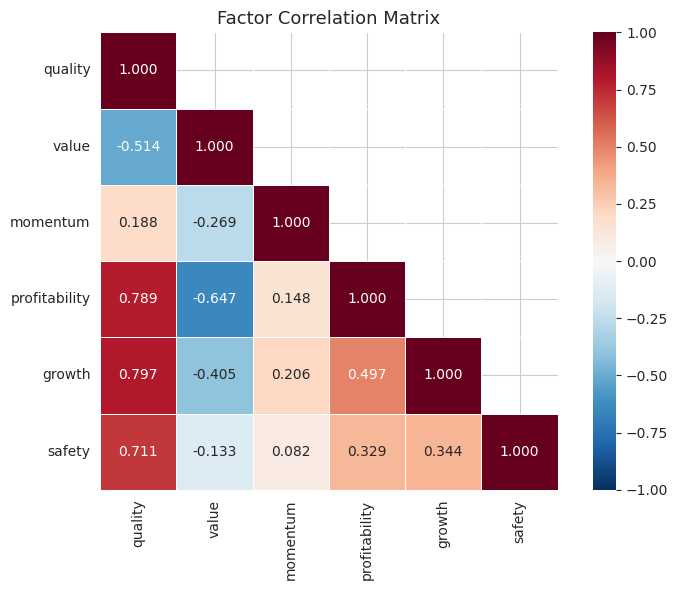


10.2 — Information Coefficient (IC)
  Forward returns non-null: 10302

    Year        IC   p-value      n  Signif
  ----------------------------------------
    2010    0.1645    0.0219    194      **
    2011   -0.1312    0.0056    444      **
    2012   -0.0780    0.0894    475       *
    2013    0.0158    0.7302    477        
    2014   -0.0335    0.4674    472        
    2015   -0.0013    0.9777    488        
    2016    0.0470    0.2920    505        
    2017    0.0058    0.8963    508        
    2018   -0.0157    0.7230    512        
    2019    0.0935    0.0337    516      **
    2020    0.0884    0.0446    516      **
    2021   -0.0703    0.1054    532        
    2022   -0.0607    0.1614    534        
    2023    0.0705    0.1065    525        
    2024    0.3643    0.0801     24       *

  IC mean:  0.0306
  IC std:   0.1204
  ICIR:     0.2543
  IC > 0:   8 / 15 years (53%)


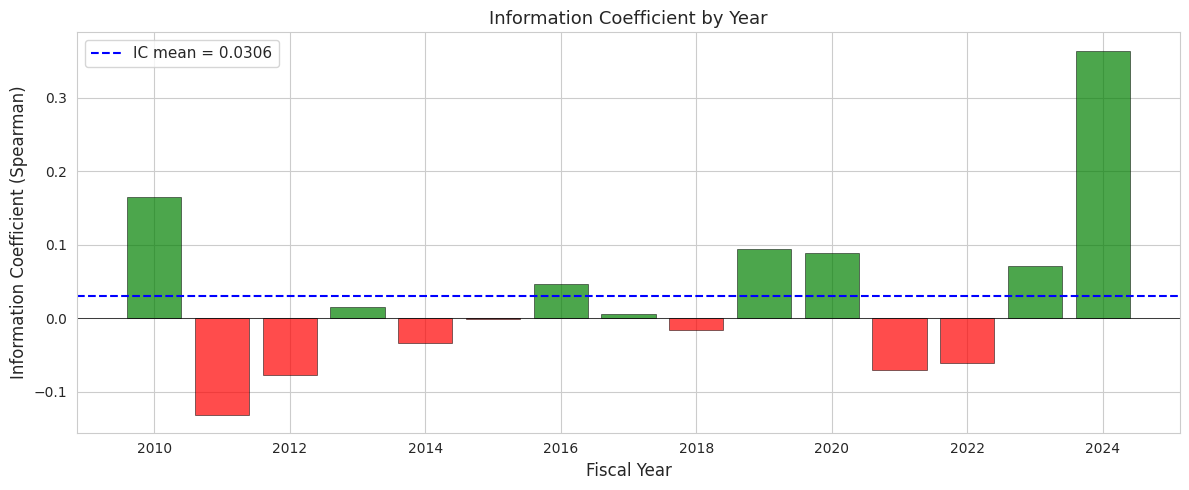


10.3 — Ranking Stability Test
     Year Pair   Rank Corr       n
     2010-2011      0.5974     191
     2011-2012      0.4616     444
     2012-2013      0.3931     470
     2013-2014      0.4170     464
     2014-2015      0.3463     462
     2015-2016      0.3377     489
     2016-2017      0.4061     503
     2017-2018      0.4002     501
     2018-2019      0.4010     504
     2019-2020      0.4495     501
     2020-2021      0.4166     509
     2021-2022      0.3610     531
     2022-2023      0.4589     533
     2023-2024      0.4318     521
     2024-2025      0.4051      23

  Mean rank correlation: 0.4189


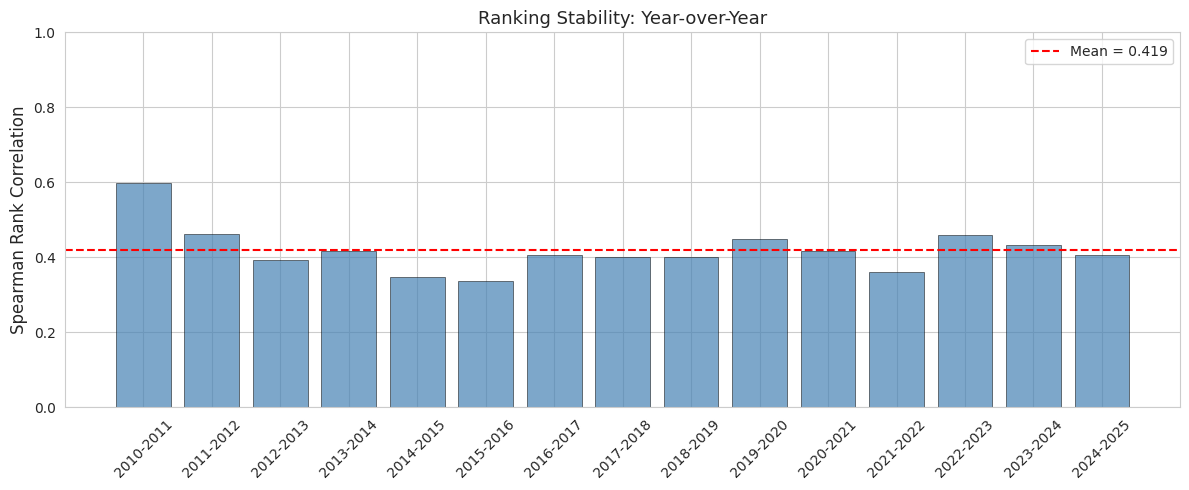


10.4 — Quintile Analysis

  Average return by quintile:
    Q1: 15.60%
    Q2: 12.84%
    Q3: 11.54%
    Q4: 12.64%
    Q5: 15.13%

  Q5-Q1 Spread:
    Mean: -0.47%
    % years Q5 > Q1: 57%
    T-stat: -0.324, p-value: 0.7511


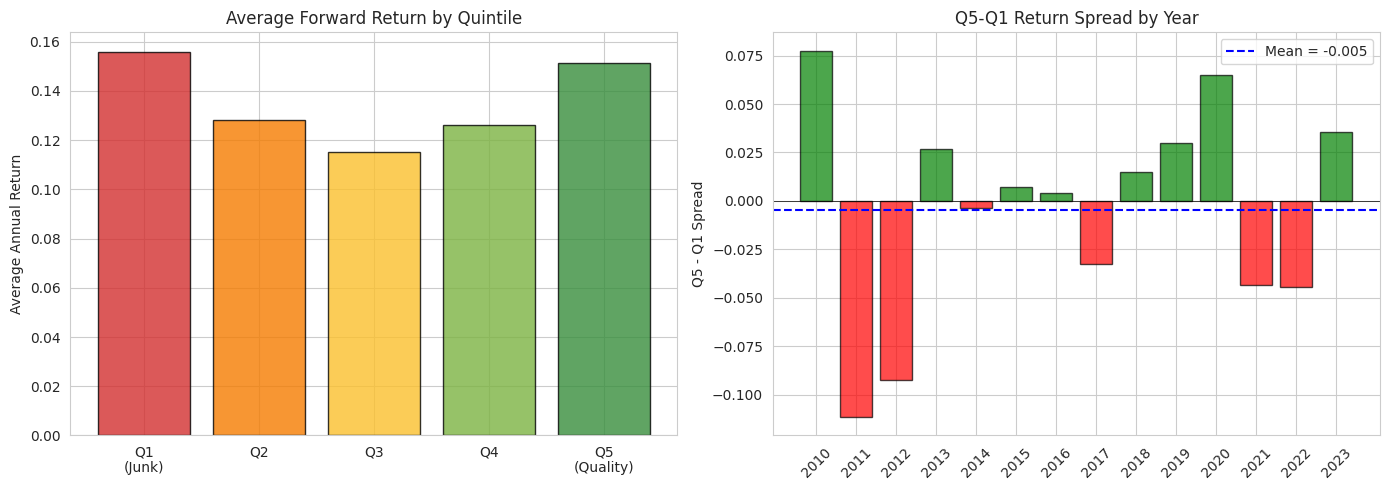


✓ Section 10 complete


In [44]:
# ============================================================
# SECCIÓN 10 — VALIDACIÓN ACADÉMICA
# ============================================================

# ─────────────────────────────────────────────
# 10.1 — Factor Correlation Heatmap
# ─────────────────────────────────────────────

df_valid = df_master.dropna(subset=['quality', 'value', 'momentum', 'combined', 'score_final'])
print(f"10.1 — Factor Correlations")
print(f"  Valid observations: {len(df_valid)}, Unique RICs: {df_valid['ric'].nunique()}")

factor_cols = ['quality', 'value', 'momentum', 'profitability', 'growth', 'safety']
corr_matrix = df_valid[factor_cols].corr()
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Factor Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/outputs/factor_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 10.2 — Information Coefficient (IC)
# ─────────────────────────────────────────────

df_master = df_master.sort_values(['ric', 'fiscal_year']).reset_index(drop=True)
df_master['price_next'] = df_master.groupby('ric')['price_close'].shift(-1)
df_master['return_forward'] = (df_master['price_next'] / df_master['price_close'].replace(0, np.nan)) - 1

print(f"\n10.2 — Information Coefficient (IC)")
print(f"  Forward returns non-null: {df_master['return_forward'].notna().sum()}")

ic_results = []
for year in sorted(df_master['fiscal_year'].unique()):
    year_data = df_master[(df_master['fiscal_year'] == year)].dropna(subset=['score_final', 'return_forward'])
    if len(year_data) >= 20:
        result = spearmanr(year_data['score_final'].values, year_data['return_forward'].values)
        ic_results.append({
            'fiscal_year': year,
            'IC': result.statistic if hasattr(result, 'statistic') else result[0],
            'p_value': result.pvalue if hasattr(result, 'pvalue') else result[1],
            'n': len(year_data)
        })

df_ic = pd.DataFrame(ic_results)

if len(df_ic) > 0:
    ic_mean = df_ic['IC'].mean()
    ic_std = df_ic['IC'].std()
    icir = ic_mean / ic_std if ic_std > 0 else np.nan

    print(f"\n  {'Year':>6s}  {'IC':>8s}  {'p-value':>8s}  {'n':>5s}  {'Signif':>6s}")
    print(f"  {'-'*40}")
    for _, row in df_ic.iterrows():
        sig = "**" if row['p_value'] < 0.05 else ("*" if row['p_value'] < 0.10 else "")
        print(f"  {int(row['fiscal_year']):>6d}  {row['IC']:>8.4f}  {row['p_value']:>8.4f}  {int(row['n']):>5d}  {sig:>6s}")

    print(f"\n  IC mean:  {ic_mean:.4f}")
    print(f"  IC std:   {ic_std:.4f}")
    print(f"  ICIR:     {icir:.4f}")
    print(f"  IC > 0:   {(df_ic['IC'] > 0).sum()} / {len(df_ic)} years ({(df_ic['IC'] > 0).mean()*100:.0f}%)")

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['green' if ic > 0 else 'red' for ic in df_ic['IC']]
    ax.bar(df_ic['fiscal_year'], df_ic['IC'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axhline(y=ic_mean, color='blue', linestyle='--', linewidth=1.5, label=f'IC mean = {ic_mean:.4f}')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Fiscal Year', fontsize=12)
    ax.set_ylabel('Information Coefficient (Spearman)', fontsize=12)
    ax.set_title('Information Coefficient by Year', fontsize=13)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/TFM/outputs/ic_by_year.png', dpi=150, bbox_inches='tight')
    plt.show()

# ─────────────────────────────────────────────
# 10.3 — Stability Test
# ─────────────────────────────────────────────

print(f"\n10.3 — Ranking Stability Test")

stability_results = []
years = sorted(df_master[df_master['score_final'].notna()]['fiscal_year'].unique())

for i in range(1, len(years)):
    df_prev = df_master[df_master['fiscal_year'] == years[i-1]][['ric', 'score_final']].dropna()
    df_curr = df_master[df_master['fiscal_year'] == years[i]][['ric', 'score_final']].dropna()
    merged = df_prev.merge(df_curr, on='ric', suffixes=('_prev', '_curr'))
    if len(merged) >= 20:
        result = spearmanr(merged['score_final_prev'].values, merged['score_final_curr'].values)
        corr_val = result.statistic if hasattr(result, 'statistic') else result[0]
        stability_results.append({
            'year_pair': f"{years[i-1]}-{years[i]}",
            'rank_corr': corr_val,
            'n_common': len(merged)
        })

df_stability = pd.DataFrame(stability_results)
mean_stability = df_stability['rank_corr'].mean()

print(f"  {'Year Pair':>12s}  {'Rank Corr':>10s}  {'n':>6s}")
for _, row in df_stability.iterrows():
    print(f"  {row['year_pair']:>12s}  {row['rank_corr']:>10.4f}  {int(row['n_common']):>6d}")
print(f"\n  Mean rank correlation: {mean_stability:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_stability['year_pair'], df_stability['rank_corr'],
       color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(y=mean_stability, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {mean_stability:.3f}')
ax.set_ylim(0, 1)
ax.set_ylabel('Spearman Rank Correlation', fontsize=12)
ax.set_title('Ranking Stability: Year-over-Year', fontsize=13)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/outputs/ranking_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 10.4 — Quintile Analysis
# ─────────────────────────────────────────────

print(f"\n10.4 — Quintile Analysis")

quintile_results = []
for year in sorted(df_master['fiscal_year'].unique()):
    year_data = df_master[df_master['fiscal_year'] == year].dropna(subset=['score_final', 'return_forward'])
    if len(year_data) >= 25:
        year_data = year_data.copy()
        year_data['quintile'] = pd.qcut(year_data['score_final'], 5, labels=[1, 2, 3, 4, 5])
        for q in [1, 2, 3, 4, 5]:
            q_data = year_data[year_data['quintile'] == q]
            quintile_results.append({
                'fiscal_year': year, 'quintile': q,
                'mean_return': q_data['return_forward'].mean(), 'n': len(q_data)
            })

df_quintiles = pd.DataFrame(quintile_results)

if len(df_quintiles) > 0:
    q_avg = df_quintiles.groupby('quintile')['mean_return'].mean()
    print(f"\n  Average return by quintile:")
    for q, ret in q_avg.items():
        print(f"    Q{q}: {ret*100:.2f}%")

    spread_by_year = []
    for year in df_quintiles['fiscal_year'].unique():
        yr = df_quintiles[df_quintiles['fiscal_year'] == year]
        q5 = yr[yr['quintile'] == 5]['mean_return'].values[0]
        q1 = yr[yr['quintile'] == 1]['mean_return'].values[0]
        spread_by_year.append({'fiscal_year': year, 'spread': q5 - q1, 'q5': q5, 'q1': q1})

    df_spread = pd.DataFrame(spread_by_year)
    mean_spread = df_spread['spread'].mean()
    pct_positive = (df_spread['spread'] > 0).mean() * 100

    if len(df_spread) >= 3:
        t_stat, t_pvalue = ttest_1samp(df_spread['spread'].values, 0)
    else:
        t_stat, t_pvalue = np.nan, np.nan

    print(f"\n  Q5-Q1 Spread:")
    print(f"    Mean: {mean_spread*100:.2f}%")
    print(f"    % years Q5 > Q1: {pct_positive:.0f}%")
    print(f"    T-stat: {t_stat:.3f}, p-value: {t_pvalue:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors_q = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
    axes[0].bar(['Q1\n(Junk)', 'Q2', 'Q3', 'Q4', 'Q5\n(Quality)'],
                q_avg.values, color=colors_q, alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('Average Annual Return')
    axes[0].set_title('Average Forward Return by Quintile')
    axes[0].axhline(y=0, color='black', linewidth=0.5)

    spread_colors = ['green' if s > 0 else 'red' for s in df_spread['spread']]
    axes[1].bar(df_spread['fiscal_year'].astype(str), df_spread['spread'],
                color=spread_colors, alpha=0.7, edgecolor='black')
    axes[1].axhline(y=mean_spread, color='blue', linestyle='--', label=f'Mean = {mean_spread:.3f}')
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    axes[1].set_ylabel('Q5 - Q1 Spread')
    axes[1].set_title('Q5-Q1 Return Spread by Year')
    axes[1].legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/TFM/outputs/quintile_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n✓ Section 10 complete")

In [45]:
# ============================================================
# 10.5 — DIAGNÓSTICO: ¿Qué explica la debilidad del IC?
# ============================================================

print("10.5 — Diagnóstico de debilidad del IC")
print("="*60)

# ─────────────────────────────────────────────
# A) IC por factor individual (¿cuál aporta y cuál resta?)
# ─────────────────────────────────────────────

print("\nA) IC por factor individual:")
print(f"  {'Factor':<15s}  {'IC mean':>8s}  {'IC>0':>6s}  {'Conclusion'}")
print(f"  {'-'*55}")

for factor in ['quality', 'value', 'momentum', 'profitability', 'growth', 'safety', 'score_final']:
    ic_list = []
    for year in sorted(df_master['fiscal_year'].unique()):
        yd = df_master[df_master['fiscal_year'] == year].dropna(subset=[factor, 'return_forward'])
        if len(yd) >= 20:
            result = spearmanr(yd[factor].values, yd['return_forward'].values)
            ic_val = result.statistic if hasattr(result, 'statistic') else result[0]
            ic_list.append(ic_val)
    if ic_list:
        ic_m = np.mean(ic_list)
        pct_pos = sum(1 for x in ic_list if x > 0) / len(ic_list) * 100
        conclusion = "✓ predictivo" if ic_m > 0.03 else ("~ neutral" if ic_m > -0.03 else "✗ contrario")
        print(f"  {factor:<15s}  {ic_m:>8.4f}  {pct_pos:>5.0f}%  {conclusion}")

# ─────────────────────────────────────────────
# B) IC sin sector neutralization (¿la neutralización diluye?)
# ─────────────────────────────────────────────

print(f"\nB) IC del Combined (PRE sector neutralization) vs score_final (POST):")
for label, col in [('combined (pre)', 'combined'), ('score_final (post)', 'score_final')]:
    ic_list = []
    for year in sorted(df_master['fiscal_year'].unique()):
        yd = df_master[df_master['fiscal_year'] == year].dropna(subset=[col, 'return_forward'])
        if len(yd) >= 20:
            result = spearmanr(yd[col].values, yd['return_forward'].values)
            ic_val = result.statistic if hasattr(result, 'statistic') else result[0]
            ic_list.append(ic_val)
    if ic_list:
        print(f"  {label:<25s}  IC mean = {np.mean(ic_list):.4f}  IC>0: {sum(1 for x in ic_list if x > 0)}/{len(ic_list)}")

# ─────────────────────────────────────────────
# C) Quintiles SIN sector neutralization
# ─────────────────────────────────────────────

print(f"\nC) Quintile analysis usando 'combined' (sin neutralización sectorial):")
q_results_raw = []
for year in sorted(df_master['fiscal_year'].unique()):
    yd = df_master[df_master['fiscal_year'] == year].dropna(subset=['combined', 'return_forward'])
    if len(yd) >= 25:
        yd = yd.copy()
        yd['quintile'] = pd.qcut(yd['combined'], 5, labels=[1, 2, 3, 4, 5])
        for q in [1, 2, 3, 4, 5]:
            qd = yd[yd['quintile'] == q]
            q_results_raw.append({'fiscal_year': year, 'quintile': q, 'mean_return': qd['return_forward'].mean()})

df_q_raw = pd.DataFrame(q_results_raw)
if len(df_q_raw) > 0:
    q_avg_raw = df_q_raw.groupby('quintile')['mean_return'].mean()
    for q, ret in q_avg_raw.items():
        print(f"    Q{q}: {ret*100:.2f}%")

    spreads_raw = []
    for year in df_q_raw['fiscal_year'].unique():
        yr = df_q_raw[df_q_raw['fiscal_year'] == year]
        q5 = yr[yr['quintile'] == 5]['mean_return'].values[0]
        q1 = yr[yr['quintile'] == 1]['mean_return'].values[0]
        spreads_raw.append(q5 - q1)
    print(f"    Spread Q5-Q1: {np.mean(spreads_raw)*100:.2f}%")
    print(f"    % years Q5>Q1: {sum(1 for s in spreads_raw if s > 0)/len(spreads_raw)*100:.0f}%")

# ─────────────────────────────────────────────
# D) ¿Quality protege en drawdowns? (risk-adjusted view)
# ─────────────────────────────────────────────

print(f"\nD) Quality en años malos vs buenos:")
print(f"  {'Year':>6s}  {'Mkt Ret':>10s}  {'Q5 Ret':>10s}  {'Q1 Ret':>10s}  {'Q5-Q1':>10s}  {'Regime'}")
print(f"  {'-'*65}")

for year in sorted(df_master['fiscal_year'].unique()):
    yd = df_master[df_master['fiscal_year'] == year].dropna(subset=['score_final', 'return_forward'])
    if len(yd) >= 25:
        yd = yd.copy()
        yd['quintile'] = pd.qcut(yd['score_final'], 5, labels=[1, 2, 3, 4, 5])
        mkt_ret = yd['return_forward'].mean()
        q5_ret = yd[yd['quintile'] == 5]['return_forward'].mean()
        q1_ret = yd[yd['quintile'] == 1]['return_forward'].mean()
        regime = "DOWN" if mkt_ret < 0 else ("FLAT" if mkt_ret < 0.05 else "UP")
        print(f"  {year:>6d}  {mkt_ret:>10.4f}  {q5_ret:>10.4f}  {q1_ret:>10.4f}  {q5_ret-q1_ret:>10.4f}  {regime}")

# Summary for down markets
print(f"\n  Flight to quality test:")
yd_all = []
for year in sorted(df_master['fiscal_year'].unique()):
    yd = df_master[df_master['fiscal_year'] == year].dropna(subset=['score_final', 'return_forward'])
    if len(yd) >= 25:
        yd = yd.copy()
        yd['quintile'] = pd.qcut(yd['score_final'], 5, labels=[1, 2, 3, 4, 5])
        mkt_ret = yd['return_forward'].mean()
        q5_ret = yd[yd['quintile'] == 5]['return_forward'].mean()
        q1_ret = yd[yd['quintile'] == 1]['return_forward'].mean()
        yd_all.append({'year': year, 'mkt': mkt_ret, 'q5': q5_ret, 'q1': q1_ret, 'spread': q5_ret - q1_ret})

df_regime = pd.DataFrame(yd_all)
down_years = df_regime[df_regime['mkt'] < 0.05]
up_years = df_regime[df_regime['mkt'] >= 0.05]

if len(down_years) > 0:
    print(f"  Down/flat markets (<5%): Q5-Q1 avg = {down_years['spread'].mean()*100:.2f}%, n={len(down_years)} years")
if len(up_years) > 0:
    print(f"  Up markets (>=5%):       Q5-Q1 avg = {up_years['spread'].mean()*100:.2f}%, n={len(up_years)} years")

print(f"\n✓ Diagnostic complete")

10.5 — Diagnóstico de debilidad del IC

A) IC por factor individual:
  Factor            IC mean    IC>0  Conclusion
  -------------------------------------------------------
  quality            0.0803     67%  ✓ predictivo
  value             -0.0766     30%  ✗ contrario
  momentum           0.0371     61%  ✓ predictivo
  profitability      0.0807     75%  ✓ predictivo
  growth             0.0942     67%  ✓ predictivo
  safety             0.0128     50%  ~ neutral
  score_final        0.0306     53%  ✓ predictivo

B) IC del Combined (PRE sector neutralization) vs score_final (POST):
  combined (pre)             IC mean = 0.0389  IC>0: 9/15
  score_final (post)         IC mean = 0.0306  IC>0: 8/15

C) Quintile analysis usando 'combined' (sin neutralización sectorial):
    Q1: 14.49%
    Q2: 12.65%
    Q3: 12.08%
    Q4: 12.81%
    Q5: 15.71%
    Spread Q5-Q1: 1.21%
    % years Q5>Q1: 71%

D) Quality en años malos vs buenos:
    Year     Mkt Ret      Q5 Ret      Q1 Ret       Q5-Q1  Reg

In [46]:
# ============================================================
# SECCIÓN 11 — OUTPUT FINAL (múltiples universos)
# ============================================================

output_path = '/content/drive/MyDrive/TFM/outputs/'

# ─────────────────────────────────────────────
# 11.1 — Crear scores combinados alternativos
# ─────────────────────────────────────────────

# Combo 1: Quality only
df_master['score_quality_only'] = df_master.groupby('fiscal_year')['quality'].transform(rank_zscore)

# Combo 2: Quality + Momentum (50/50)
df_master['qm_raw'] = 0.5 * df_master['quality'] + 0.5 * df_master['momentum']
df_master['score_quality_momentum'] = df_master.groupby('fiscal_year')['qm_raw'].transform(rank_zscore)

# Combo 3: Quality + Value + Momentum (1/3 each) — already exists as 'combined'
df_master['score_qvm'] = df_master.groupby('fiscal_year')['combined'].transform(rank_zscore)

# Combo 4: Quality + Value + Momentum with sector neutralization — already exists as 'score_final'
# (keeping for comparison)

print("11.1 — Score variants created")
scores = {
    'quality_only':      'score_quality_only',
    'quality_momentum':  'score_quality_momentum',
    'qvm':               'score_qvm',
    'qvm_sector_neutral':'score_final',
}

for name, col in scores.items():
    n = df_master[col].notna().sum()
    print(f"  {name:<25s}  non-null: {n}")

# ─────────────────────────────────────────────
# 11.2 — Quick IC comparison across variants
# ─────────────────────────────────────────────

print(f"\n11.2 — IC comparison across score variants:")
print(f"  {'Variant':<25s}  {'IC mean':>8s}  {'ICIR':>8s}  {'IC>0':>6s}  {'Q5-Q1':>8s}  {'%Q5>Q1':>7s}")
print(f"  {'-'*70}")

for name, col in scores.items():
    ic_list = []
    spread_list = []
    for year in sorted(df_master['fiscal_year'].unique()):
        yd = df_master[df_master['fiscal_year'] == year].dropna(subset=[col, 'return_forward'])
        if len(yd) >= 25:
            result = spearmanr(yd[col].values, yd['return_forward'].values)
            ic_val = result.statistic if hasattr(result, 'statistic') else result[0]
            ic_list.append(ic_val)

            yd = yd.copy()
            yd['q'] = pd.qcut(yd[col], 5, labels=[1,2,3,4,5])
            q5 = yd[yd['q']==5]['return_forward'].mean()
            q1 = yd[yd['q']==1]['return_forward'].mean()
            spread_list.append(q5 - q1)

    if ic_list:
        ic_m = np.mean(ic_list)
        ic_s = np.std(ic_list)
        icir = ic_m / ic_s if ic_s > 0 else 0
        pct_pos = sum(1 for x in ic_list if x > 0) / len(ic_list) * 100
        sp_m = np.mean(spread_list)
        pct_q5 = sum(1 for s in spread_list if s > 0) / len(spread_list) * 100
        print(f"  {name:<25s}  {ic_m:>8.4f}  {icir:>8.4f}  {pct_pos:>5.0f}%  {sp_m:>8.4f}  {pct_q5:>6.0f}%")

# ─────────────────────────────────────────────
# 11.3 — Generate selected universes (top 60%) for each variant
# ─────────────────────────────────────────────

print(f"\n11.3 — Selected universes (Top 60%):")

def select_top_pct(group, col, pct=0.60):
    threshold = group[col].quantile(1 - pct)
    return group[group[col] >= threshold]

for name, col in scores.items():
    df_sel = df_master.dropna(subset=[col]).groupby('fiscal_year', group_keys=False).apply(
        lambda g: select_top_pct(g, col)
    )

    # Export
    export_cols = ['ric', 'fiscal_year', 'sector', 'period_end_date',
                   'market_cap', 'price_close', col,
                   'quality', 'value', 'momentum',
                   'profitability', 'growth', 'safety']
    export_cols = [c for c in export_cols if c in df_sel.columns]

    filename = f'selected_universe_{name}.csv'
    df_sel[export_cols].to_csv(output_path + filename, index=False)

    n_years = df_sel['fiscal_year'].nunique()
    avg_per_year = len(df_sel) / n_years if n_years > 0 else 0
    print(f"  {name:<25s}  {len(df_sel):>6d} rows, ~{avg_per_year:.0f}/year → {filename}")

# ─────────────────────────────────────────────
# 11.4 — Export full datasets
# ─────────────────────────────────────────────

# Factor scores
factor_export_cols = [
    'ric', 'fiscal_year', 'sector', 'period_end_date',
    'market_cap', 'price_close', 'common_equity', 'book_to_market',
    'quality', 'value', 'momentum', 'combined',
    'score_quality_only', 'score_quality_momentum', 'score_qvm', 'score_final',
    'profitability', 'growth', 'safety',
    'momentum_raw', 'return_forward'
]
factor_export_cols = [c for c in factor_export_cols if c in df_master.columns]
df_master[factor_export_cols].to_csv(output_path + 'factor_scores.csv', index=False)

# Full master
df_master.to_csv(output_path + 'df_master.csv', index=False)

print(f"\n11.4 — Full exports:")
print(f"  factor_scores.csv: {len(df_master)} rows")
print(f"  df_master.csv:     {len(df_master)} rows")

# ─────────────────────────────────────────────
# Final summary
# ─────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  NOTEBOOK 01 — COMPLETE")
print(f"{'='*60}")
print(f"  Universe: {df_master['ric'].nunique()} total RICs")
print(f"  Effective period: {df_master['fiscal_year'].min()}-{df_master['fiscal_year'].max()}")
print(f"  4 score variants generated for HRP comparison")
print(f"\n  Factor correlations:")
print(f"    Quality-Value:    {factor_corr.loc['quality','value']:.3f}")
print(f"    Value-Momentum:   {factor_corr.loc['value','momentum']:.3f}")
print(f"    Quality-Momentum: {factor_corr.loc['quality','momentum']:.3f}")
print(f"\n  → 4 selected universes ready for Notebook 02 (HRP Portfolio)")
print(f"  → Best performing variant for stock selection: see IC comparison above")

11.1 — Score variants created
  quality_only               non-null: 7619
  quality_momentum           non-null: 7601
  qvm                        non-null: 7284
  qvm_sector_neutral         non-null: 7282

11.2 — IC comparison across score variants:
  Variant                     IC mean      ICIR    IC>0     Q5-Q1   %Q5>Q1
  ----------------------------------------------------------------------
  quality_only                 0.0803    0.4690     67%    0.0585      67%
  quality_momentum             0.0825    0.4337     60%    0.0712      53%
  qvm                          0.0164    0.1610     57%    0.0121      71%
  qvm_sector_neutral           0.0068    0.0877     50%   -0.0047      57%

11.3 — Selected universes (Top 60%):
  quality_only                 4573 rows, ~286/year → selected_universe_quality_only.csv
  quality_momentum             4561 rows, ~285/year → selected_universe_quality_momentum.csv
  qvm                          4369 rows, ~273/year → selected_universe_qvm.csv
 

In [47]:
# ============================================================
# COMPARACIÓN: Nuestro modelo vs AQR Long-Short Equity Fund
# Posiciones long de AQR a diciembre 2024
# ============================================================

# AQR positions matched to our S&P 500 universe (87 empresas)
aqr_positions = {
    "PM.N": 0.9201,
    "AAPL.OQ": 0.859,
    "DTE.N": 0.7194,
    "CME.OQ": 0.6556,
    "EIX.N": 0.6214,
    "CMCSA.OQ": 0.5594,
    "LLY.N": 0.5403,
    "WMT.OQ": 0.5124,
    "AMZN.OQ": 0.5043,
    "NVDA.OQ": 0.4783,
    "WAB.N": 0.4679,
    "XEL.OQ": 0.458,
    "ITW.N": 0.4177,
    "VRSN.OQ": 0.4132,
    "SHW.N": 0.4078,
    "JNJ.N": 0.4073,
    "AVGO.OQ": 0.4038,
    "ANET.N": 0.4004,
    "HLT.N": 0.3996,
    "PKG.N": 0.3934,
    "MRK.N": 0.3676,
    "FTNT.OQ": 0.3632,
    "AEP.OQ": 0.3587,
    "NFLX.OQ": 0.3575,
    "EVRG.OQ": 0.3488,
    "CTAS.OQ": 0.3484,
    "MA.N": 0.3345,
    "MMM.N": 0.3257,
    "MSFT.OQ": 0.3197,
    "CCI.N": 0.3134,
    "ABT.N": 0.3102,
    "PNC.N": 0.3053,
    "PPL.N": 0.3047,
    "FICO.N": 0.3028,
    "SBAC.OQ": 0.2963,
    "NOW.N": 0.296,
    "MRSH.N": 0.2957,
    "ADBE.OQ": 0.2937,
    "TRV.N": 0.2897,
    "A.N": 0.2826,
    "SYK.N": 0.2749,
    "MSI.N": 0.2696,
    "AMP.N": 0.2656,
    "KMI.N": 0.2636,
    "VTR.N": 0.2583,
    "ALL.N": 0.2542,
    "CFG.N": 0.2535,
    "AMT.N": 0.2494,
    "STZ.N": 0.2437,
    "NOC.N": 0.2428,
    "WEC.N": 0.2418,
    "BSX.N": 0.2381,
    "AZO.N": 0.2348,
    "GDDY.N": 0.2346,
    "WELL.N": 0.2319,
    "WRB.N": 0.2303,
    "BMY.N": 0.2263,
    "COF.N": 0.2236,
    "INCY.OQ": 0.2181,
    "DASH.OQ": 0.2172,
    "HIG.N": 0.2168,
    "COST.OQ": 0.2136,
    "EXPE.OQ": 0.2119,
    "CNC.N": 0.2068,
    "JBL.N": 0.2052,
    "APH.N": 0.2024,
    "NVR.N": 0.1938,
    "BR.N": 0.1932,
    "ZTS.N": 0.191,
    "PGR.N": 0.1907,
    "ROST.OQ": 0.1839,
    "CMI.N": 0.1838,
    "TRGP.N": 0.1764,
    "ATO.N": 0.1733,
    "UBER.N": 0.1676,
    "DAL.N": 0.165,
    "ECL.N": 0.1634,
    "MAS.N": 0.1622,
    "HBAN.OQ": 0.16,
    "UAL.OQ": 0.1528,
    "PYPL.OQ": 0.1492,
    "RF.N": 0.145,
    "ORCL.N": 0.1437,
    "COP.N": 0.1205,
    "GEV.N": 0.1055,
    "FIS.N": 0.0834,
    "BKR.OQ": 0.0819,
}

# Cross-reference with our scores for fiscal_year 2024
df_2024 = df_master[df_master['fiscal_year'] == 2024].copy()

# Mark which companies are in AQR's portfolio
df_2024['in_aqr'] = df_2024['ric'].isin(aqr_positions.keys())
df_2024['aqr_weight'] = df_2024['ric'].map(aqr_positions).fillna(0)

print("=" * 70)
print("COMPARACIÓN: Nuestro Modelo vs AQR Long-Short Fund (dic 2024)")
print("=" * 70)

# For each strategy, check overlap
for name, col in [('Quality Only', 'score_quality_only'),
                   ('Quality + Momentum', 'score_quality_momentum'),
                   ('QVM', 'score_qvm')]:

    valid = df_2024.dropna(subset=[col])

    # Our top 60%
    threshold = valid[col].quantile(0.40)
    our_selected = set(valid[valid[col] >= threshold]['ric'])
    aqr_set = set(aqr_positions.keys())

    # Overlap
    overlap = our_selected & aqr_set
    aqr_in_universe = aqr_set & set(valid['ric'])

    print(f"\n--- {name} ---")
    print(f"  Nuestro universo seleccionado: {len(our_selected)} empresas")
    print(f"  AQR posiciones (en nuestro universo): {len(aqr_in_universe)}")
    print(f"  Overlap: {len(overlap)} empresas ({len(overlap)/len(aqr_in_universe)*100:.0f}% de AQR)")

    # Average score of AQR positions vs non-AQR
    aqr_scores = valid[valid['ric'].isin(aqr_set)][col]
    non_aqr_scores = valid[~valid['ric'].isin(aqr_set)][col]

    print(f"  Score medio AQR positions: {aqr_scores.mean():.4f}")
    print(f"  Score medio non-AQR:       {non_aqr_scores.mean():.4f}")

print(f"\n{'='*70}")
print("Detalle: Posiciones AQR y nuestros scores")
print(f"{'='*70}")

# Show AQR positions with our scores
aqr_detail = df_2024[df_2024['in_aqr']].copy()
aqr_detail = aqr_detail.sort_values('aqr_weight', ascending=False)

print(f"\n{'RIC':<12s} {'AQR%':>6s}  {'Quality':>8s}  {'Value':>8s}  {'Mom':>8s}  {'QVM':>8s}  {'En Top60%':>10s}")
print("-" * 75)

for _, row in aqr_detail.head(40).iterrows():
    qvm = row.get('score_qvm', np.nan)
    q = row.get('quality', np.nan)
    v = row.get('value', np.nan)
    m = row.get('momentum', np.nan)

    valid_qvm = df_2024.dropna(subset=['score_qvm'])
    if not pd.isna(qvm):
        thresh = valid_qvm['score_qvm'].quantile(0.40)
        in_top = "SI" if qvm >= thresh else "NO"
    else:
        in_top = "N/A"

    q_str = f"{q:.3f}" if not pd.isna(q) else "N/A"
    v_str = f"{v:.3f}" if not pd.isna(v) else "N/A"
    m_str = f"{m:.3f}" if not pd.isna(m) else "N/A"
    qvm_str = f"{qvm:.3f}" if not pd.isna(qvm) else "N/A"

    print(f"{row['ric']:<12s} {row['aqr_weight']:>6.4f}  {q_str:>8s}  {v_str:>8s}  {m_str:>8s}  {qvm_str:>8s}  {in_top:>10s}")

# Quintile analysis
print(f"\n{'='*70}")
print("¿En qué quintil caen las posiciones de AQR según nuestro modelo?")
print(f"{'='*70}")

for name, col in [('Quality Only', 'score_quality_only'),
                   ('Quality + Momentum', 'score_quality_momentum'),
                   ('QVM', 'score_qvm')]:
    valid = df_2024.dropna(subset=[col]).copy()
    valid['quintile'] = pd.qcut(valid[col], 5, labels=['Q1 (Junk)', 'Q2', 'Q3', 'Q4', 'Q5 (Quality)'])

    aqr_quintiles = valid[valid['ric'].isin(aqr_positions.keys())]['quintile'].value_counts().sort_index()

    print(f"\n  {name}:")
    total_aqr = aqr_quintiles.sum()
    for q, n in aqr_quintiles.items():
        bar = "█" * int(n / total_aqr * 30)
        print(f"    {q:<15s}  {n:>3d} ({n/total_aqr*100:>5.1f}%)  {bar}")

COMPARACIÓN: Nuestro Modelo vs AQR Long-Short Fund (dic 2024)

--- Quality Only ---
  Nuestro universo seleccionado: 338 empresas
  AQR posiciones (en nuestro universo): 85
  Overlap: 58 empresas (68% de AQR)
  Score medio AQR positions: 0.1760
  Score medio non-AQR:       -0.0312

--- Quality + Momentum ---
  Nuestro universo seleccionado: 338 empresas
  AQR posiciones (en nuestro universo): 85
  Overlap: 62 empresas (73% de AQR)
  Score medio AQR positions: 0.3780
  Score medio non-AQR:       -0.0671

--- QVM ---
  Nuestro universo seleccionado: 319 empresas
  AQR posiciones (en nuestro universo): 77
  Overlap: 51 empresas (66% de AQR)
  Score medio AQR positions: 0.1841
  Score medio non-AQR:       -0.0312

Detalle: Posiciones AQR y nuestros scores

RIC            AQR%   Quality     Value       Mom       QVM   En Top60%
---------------------------------------------------------------------------
PM.N         0.9201     0.519       N/A     1.026       N/A         N/A
AAPL.OQ      0.85